# Práctica: Comparación de modelos de regresión

**Materia:** Tópicos de Big Data
**Tema:** Introducción al aprendizaje supervisado mediante modelos de regresión
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn

---

## 1. Objetivo

Construir diferentes modelos de aprendizaje supervisado para realizar **proyecciones del número de nacimientos y defunciones** de un país, utilizando datos históricos.

Durante la práctica se implementarán y compararán visualmente tres modelos:

1. Regresión lineal
2. Regresión polinomial
3. Random Forest Regressor

Al finalizar, podrás observar cómo **diferentes modelos generan predicciones diferentes utilizando exactamente los mismos datos**.

> **Nota:** En esta práctica **no** se realizará todavía la evaluación formal de los modelos. La evaluación mediante métricas se realizará en la siguiente sesión.

---

## 2. Dataset

Utilizaremos información de **Our World in Data (OWID)** sobre nacimientos y defunciones, que incluye datos históricos y proyecciones hasta el año 2100.

Fuente: *Our World in Data – Births and deaths projected to 2100* (basado en las estimaciones y proyecciones de la ONU).

El dataset contiene información por **país (o región) y año**.

# PARTE 1. Importar las bibliotecas

En esta práctica utilizaremos:

* **Pandas** para trabajar con el dataset.
* **NumPy** para trabajar con arreglos y preparar datos.
* **Matplotlib** para visualizar los datos y las predicciones.
* **Scikit-learn** para construir los modelos de Machine Learning.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar el dataset

## 3. Cargar los datos

Leemos el archivo CSV directamente desde la página de OWID.

> **Si no hay internet (o la descarga falla):** descarga el CSV desde la URL de la celda siguiente, guárdalo en la misma carpeta que este notebook con el nombre `births-and-deaths-projected-to-2100.csv` y vuelve a ejecutar la celda. El código lo detecta automáticamente.

In [111]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## 4. Explorar el dataset

Observemos la estructura del `DataFrame`.

In [112]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39562 entries, 0 to 39561
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   entity                                               39562 non-null  str    
 1   code                                                 38354 non-null  str    
 2   year                                                 39562 non-null  int64  
 3   deaths__sex_all__age_all__variant_estimates          18944 non-null  float64
 4   deaths__sex_all__age_all__variant_medium__projected  19712 non-null  float64
 5   births__sex_all__age_all__variant_estimates          19166 non-null  float64
 6   births__sex_all__age_all__variant_medium__projected  19943 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 2.1 MB


In [114]:
df.head(10)

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN
5,Afghanistan,AFG,1955,286725.0,NaN,417650.0,NaN
6,Afghanistan,AFG,1956,286654.0,NaN,425071.0,NaN
7,Afghanistan,AFG,1957,286114.0,NaN,432044.0,NaN
8,Afghanistan,AFG,1958,285911.0,NaN,439867.0,NaN
9,Afghanistan,AFG,1959,285500.0,NaN,447510.0,NaN


Revisemos las entidades disponibles:

In [115]:
print("Número de entidades:", df["entity"].nunique())
df["entity"].unique()

Número de entidades: 262


<StringArray>
[      'Afghanistan',            'Africa',       'Africa (UN)',
           'Albania',           'Algeria',    'American Samoa',
     'Americas (UN)',           'Andorra',            'Angola',
          'Anguilla',
 ...
           'Vanuatu',           'Vatican',         'Venezuela',
           'Vietnam', 'Wallis and Futuna',    'Western Sahara',
             'World',             'Yemen',            'Zambia',
          'Zimbabwe']
Length: 262, dtype: str

### Pregunta

**¿Cuál es la unidad de observación de cada fila del dataset?**

Cada fila representa el número de nacimientos y defunciones registrados para una entidad en un año específico



## 5. Preparar los nombres de las columnas

Al explorar el dataset notamos dos cosas:

1. Los nombres de las columnas son largos y difíciles de escribir.
2. Los **datos históricos** (`..._variant_estimates`) y las **proyecciones de la ONU** (`..._variant_medium__projected`) vienen en **columnas separadas**. Cuando una fila es histórica, la columna de proyección está vacía (`NaN`), y viceversa.

Vamos a renombrar las columnas y a crear dos columnas unificadas, `births` y `deaths`, que contengan el dato histórico cuando existe y la proyección de OWID cuando no.

In [116]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})


df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [117]:
df_inicial = df.copy()
df_inicial.head(3)

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN


In [118]:
# Columna unificada: dato histórico si existe; si no, la proyección de OWID
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])
df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


# PARTE 3. Seleccionar un país

## 6. Seleccionar México

Para esta práctica utilizaremos México.

In [119]:
pais = "China"

df_china = df[df["Entity"] == pais]

df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


In [120]:
print("Rango de años:", df_china["Year"].min(), "-", df_china["Year"].max())
print("Número de filas:", df_china.shape[0])

Rango de años: 1950 - 2100
Número de filas: 151


## 7. Revisar las variables disponibles

Identifica las columnas correspondientes a: **año**, **nacimientos** y **defunciones**.

In [121]:
df_china.columns

Index(['Entity', 'Code', 'Year', 'deaths_estimates', 'deaths_projected',
       'births_estimates', 'births_projected', 'births', 'deaths'],
      dtype='str')

Para esta práctica utilizaremos:

```text
Year
births
deaths
```

# PARTE 4. Explorar visualmente los datos

## 8. Nacimientos a través del tiempo

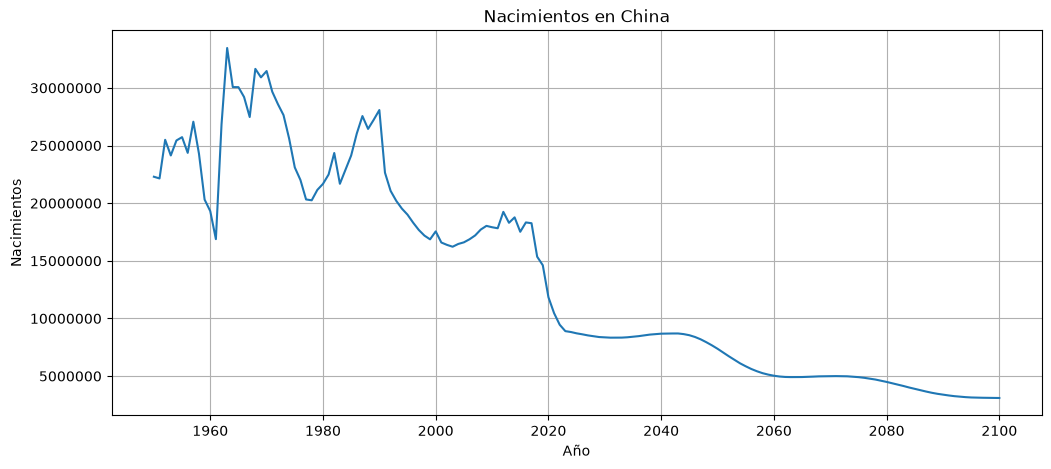

In [122]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_china["Year"],
    df_china["births"]
)

plt.title("Nacimientos en China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

## 9. Defunciones a través del tiempo

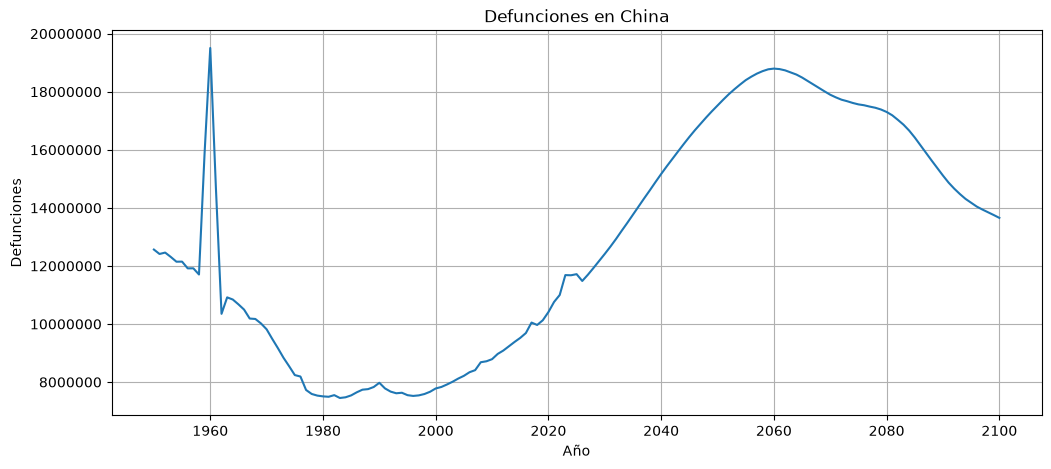

In [123]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_china["Year"],
    df_china["deaths"]
)

plt.title("Defunciones en China")
plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.grid()
plt.show()

### Preguntas de observación

1. ¿Los nacimientos presentan una tendencia constante?
R= No, para nada, ya que Sube y baja varias veces desde antes de 1960, se cae en picada en 1960 y despues tiene un gran pico de aumento, aunque sigue con altibajos, y ya desde los 90s empieza a bajar de forma más sostenida hasta desplomarse todavía más rápido después de 2020
2. ¿Las defunciones presentan una tendencia constante?
R= Tampoco. Empieza alta antes de 1960, baja un poco, pega un pico bien marcado en 1960, luego cae hasta un mínimo entre los 80s y 90s, se mantiene plana varias décadas, y después de 2010-2020 empieza a subir otra vez por el envejecimiento de la población
3. ¿Las dos variables parecen seguir el mismo comportamiento?
R= En el pico de 1960 si, aunque son al revés: nacimientos se desploman mientras defunciones se disparan, en el mismo año. Fuera de eso, nacimientos hace como montaña rusa con varios picos y valles, no se parecen mucho, salvo en ese momento de crisis puntual
4. ¿Observas cambios en la tendencia a través del tiempo?
R= Sí, mucho, el mas notorio es el de 1960 n ambas variables. Nacimientos tiene otro cambio fuerte desde los 90s y uno todavía más marcado después de 2020 donde bajan muchisimo. En defunciones el cambio grande es después de 2010-2020, cuando deja de estar plana y empieza a subir por el envejecimiento poblacional

# PARTE 5. Separar datos históricos y proyectados

## 10. Identificar el punto de separación

El dataset contiene **datos históricos** y **proyecciones**. Antes de separarlos, verifiquemos dónde termina uno y empieza el otro:

In [124]:
ultimo_historico = df_china.loc[df_china["births_estimates"].notna(), "Year"].max()
primera_proyeccion = df_china.loc[df_china["births_projected"].notna(), "Year"].min()

print("Último año con dato histórico:", ultimo_historico)
print("Primer año con proyección de OWID:", primera_proyeccion)

Último año con dato histórico: 2023
Primer año con proyección de OWID: 2024


Para esta práctica utilizaremos como punto de separación el **año 2023**. Creamos dos `DataFrames`:

In [125]:
df_historico = df_china[
    df_china["Year"] <= 2023
]

df_proyectado = df_china[
    df_china["Year"] > 2023
]

print(df_historico.head(3))
print(df_proyectado.head(3))

     Entity Code  Year  deaths_estimates  deaths_projected  births_estimates  \
7097  China  CHN  1950        12564023.0               NaN        22293376.0   
7098  China  CHN  1951        12411701.0               NaN        22144814.0   
7099  China  CHN  1952        12459848.0               NaN        25496318.0   

      births_projected      births      deaths  
7097               NaN  22293376.0  12564023.0  
7098               NaN  22144814.0  12411701.0  
7099               NaN  25496318.0  12459848.0  
     Entity Code  Year  deaths_estimates  deaths_projected  births_estimates  \
7171  China  CHN  2024               NaN        11678348.0               NaN   
7172  China  CHN  2025               NaN        11716328.0               NaN   
7173  China  CHN  2026               NaN        11482042.0               NaN   

      births_projected     births      deaths  
7171         8822056.0  8822056.0  11678348.0  
7172         8709352.0  8709352.0  11716328.0  
7173         86252

In [126]:
print("Histórico  ->", df_historico.shape, "| años:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado ->", df_proyectado.shape, "| años:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Histórico  -> (74, 9) | años: 1950 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


Comprobemos que no haya valores faltantes en las variables que vamos a utilizar para entrenar:

In [127]:
df_historico[["Year", "births", "deaths"]].isna().sum()

Year      0
births    0
deaths    0
dtype: int64

# PARTE 6. Preparar las variables para Machine Learning

## 11. Definir X e y

Para nuestro primer modelo utilizaremos:

* **X:** año → la **variable predictora**
* **y:** número de nacimientos → la **variable objetivo**

In [128]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

In [129]:
X.head()

,Year
7097,1950
7098,1951
7099,1952
7100,1953
7101,1954


In [130]:
y_nacimientos.head()

7097    22293376.0
7098    22144814.0
7099    25496318.0
7100    24139416.0
7101    25438544.0
Name: births, dtype: float64

## 12. Convertir los datos a NumPy

Obtenemos los valores como arreglos de NumPy:

In [131]:
X_numpy = X.to_numpy()
y_numpy = y_nacimientos.to_numpy()

print("X_numpy.shape:", X_numpy.shape)
print("y_numpy.shape:", y_numpy.shape)

X_numpy.shape: (74, 1)
y_numpy.shape: (74,)


In [132]:
type(X_numpy), type(y_numpy)

(numpy.ndarray, numpy.ndarray)

### Observación

Scikit-learn espera normalmente que las variables predictoras tengan la forma:

```text
(número de observaciones, número de variables)
```
Es decir, que scikit-learn interpreta X como una tabla de datos.

Por eso `X` tiene **dos dimensiones**, mientras que `y` tiene una sola.

En nuestro ejemplo tenemos:

74 observaciones (registros).

1 variable predictora: año (estas son las caracteristicas o atributos usadas para la predicción).

1 variable objetivo: nacimientos (valor que deseamos predecir).

# PARTE 7. Modelo 1 – Regresión lineal

## 13. Crear el modelo

In [133]:
modelo_lineal = LinearRegression()

## 14. Entrenar el modelo

Utilizamos los datos históricos para entrenar el modelo.

In [134]:
modelo_lineal.fit(X, y_nacimientos)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-187208.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.935e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Una regresión lineal aprende una recta `y = a·x + b`. Veamos qué valores aprendió:

In [135]:
print("Pendiente (a):", modelo_lineal.coef_[0])
print("Intercepto (b):", modelo_lineal.intercept_)

Pendiente (a): -187208.31004813028
Intercepto (b): 393489519.9376378


## 15. Realizar predicciones

Utilizamos el modelo para estimar los nacimientos correspondientes a los **años históricos**.

In [136]:
predicciones_lineal = modelo_lineal.predict(X)

predicciones_lineal[:10]

array([28433315.34378374, 28246107.03373563, 28058898.72368747,
       27871690.41363937, 27684482.10359126, 27497273.7935431 ,
       27310065.483495  , 27122857.17344683, 26935648.86339873,
       26748440.55335057])

## 16. Realizar proyecciones hasta 2100

Creamos los años para los que queremos generar **nuestras propias proyecciones**.

In [137]:
anios_futuros = np.arange(2024, 2101).reshape(-1, 1)

print("Forma:", anios_futuros.shape)
anios_futuros[:10]

Forma: (77, 1)


array([[2024],
       [2025],
       [2026],
       [2027],
       [2028],
       [2029],
       [2030],
       [2031],
       [2032],
       [2033]])

> **Detalle técnico:** entrenamos el modelo con `X`, que es un `DataFrame` con una columna llamada `Year`. Scikit-learn recuerda ese nombre, así que para predecir también debemos entregarle un `DataFrame` con una columna `Year`. Si le pasáramos un arreglo de NumPy "a secas" mostraría una advertencia (*UserWarning: X does not have valid feature names*). Por eso convertimos los años futuros a `DataFrame`.

In [138]:
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2024
1,2025
2,2026
3,2027
4,2028


In [139]:
predicciones_lineal_futuras = modelo_lineal.predict(X_futuro)

In [140]:
print(predicciones_lineal_futuras[:10])

[14579900.40022212 14392692.09017396 14205483.78012586 14018275.47007769
 13831067.16002959 13643858.84998149 13456650.53993332 13269442.22988522
 13082233.91983706 12895025.60978895]


# PARTE 8. Visualizar la regresión lineal

## 17. Comparar datos históricos y predicciones

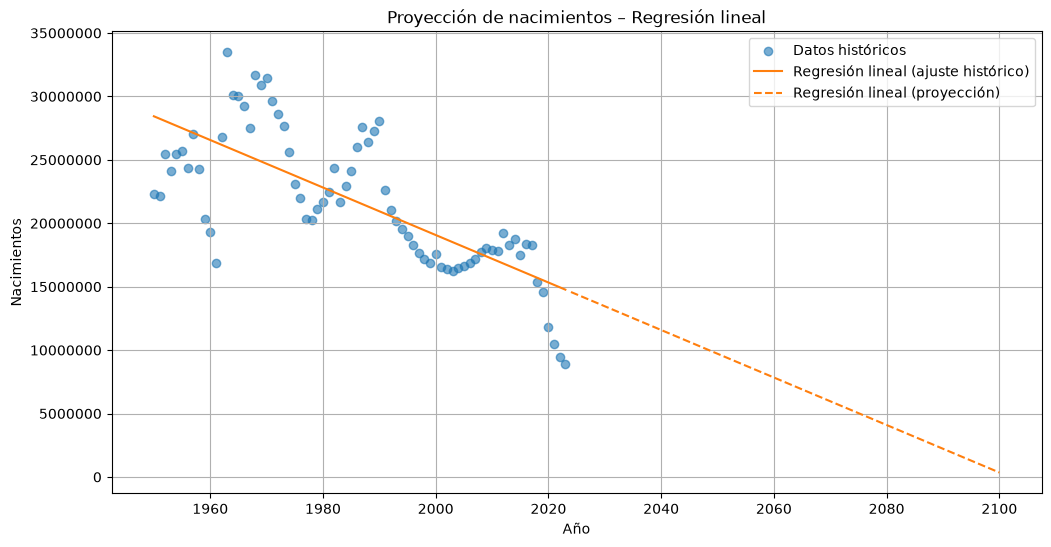

In [141]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

# Ajuste del modelo sobre los años históricos
plt.plot(
    df_historico["Year"],
    predicciones_lineal,
    color="tab:orange",
    label="Regresión lineal (ajuste histórico)"
)

# Proyección hacia el futuro
plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    linestyle="--",
    label="Regresión lineal (proyección)"
)

plt.title("Proyección de nacimientos – Regresión lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Analiza cómo continúa la tendencia histórica cuando utilizamos una **función lineal**. ¿Qué pasa con los valores hacia el año 2100?

La recta sigue bajando derechito hasta 2100 con la misma pendiente negativa que aprendió. El problema es que como los nacimientos de China nunca bajaron de forma constante, sino en subidas y bajadas muy marcadas, el modelo lineal solo agarra el promedio general de todo eso y lo convierte en una línea recta que sigue bajando para siempre, sin capturar nada de esas subidas y bajadas reales

# PARTE 9. Modelo 2 – Regresión polinomial

## 18. Crear variables polinomiales

La regresión lineal solamente puede representar una relación **lineal** entre las variables. Ahora construiremos variables polinomiales para permitir **curvas**. Utilizaremos un polinomio de **grado 2**:

$$y = a \cdot x^2 + b \cdot x + c$$

In [142]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

Transformamos `X`:

In [143]:
X_poly = poly.fit_transform(X)

X_poly[:5]

array([[1.950000e+03, 3.802500e+06],
       [1.951000e+03, 3.806401e+06],
       [1.952000e+03, 3.810304e+06],
       [1.953000e+03, 3.814209e+06],
       [1.954000e+03, 3.818116e+06]])

Observa que ahora cada año tiene **dos columnas**: el año (`x`) y el año al cuadrado (`x²`).

## 19. Crear y entrenar el modelo polinomial

Seguimos utilizando `LinearRegression`; lo único que cambió son las **variables de entrada**.

In [144]:
modelo_polinomial = LinearRegression()

modelo_polinomial.fit(
    X_poly,
    y_nacimientos
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[15379568.11, -3918.14]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.507e+10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[730030.32, 0.88]"


## 20. Generar predicciones históricas

In [145]:
predicciones_polinomiales = modelo_polinomial.predict(
    X_poly
)

## 21. Generar proyecciones hasta 2100

Transformamos los años futuros utilizando **el mismo objeto `poly`** con el que transformamos los datos de entrenamiento.

In [146]:
anios_futuros_poly = poly.transform(
    X_futuro
)

predicciones_polinomiales_futuras = modelo_polinomial.predict(
    anios_futuros_poly
)

# PARTE 10. Visualizar la regresión polinomial

## 22. Graficar las predicciones

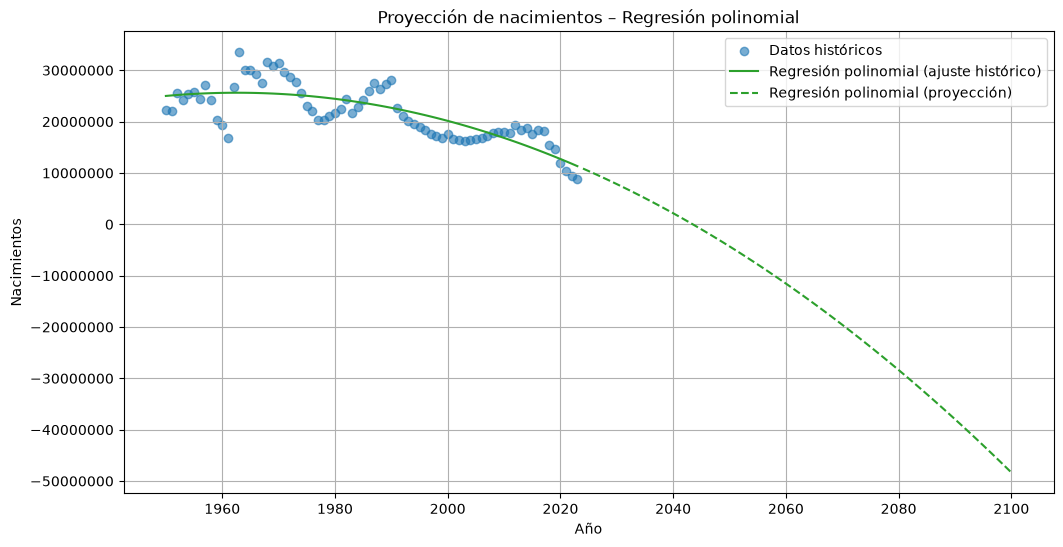

In [147]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_polinomiales,
    color="tab:green",
    label="Regresión polinomial (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    linestyle="--",
    label="Regresión polinomial (proyección)"
)

plt.title("Proyección de nacimientos – Regresión polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Compara el comportamiento de esta gráfica con el modelo de regresión lineal. ¿Se ajusta mejor a los datos históricos? ¿Qué ocurre con la proyección hacia el año 2100? ¿Los valores que predice tienen sentido para un número de nacimientos?
DIria que se ajusta mucho mejor que la lineal a la curvatura de los datos históricos, sí logra seguir algo de esas subidas y bajadas. Pero su proyección hacia 2100 es exagerada, antes de que pase mucho tiempo después de 2020 ya empieza a caer muy rápido, y para 2060 aproximadamente ya estaría dando nacimientos negativos, lo cual no tiene ningún sentido para una cantidad de personas

# PARTE 11. Modelo 3 – Random Forest

## 23. Crear el modelo

Un **Random Forest** está formado por muchos árboles de decisión. Utilizaremos `RandomForestRegressor`.

In [148]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

## 24. Entrenar el modelo

In [149]:
modelo_rf.fit(
    X,
    y_nacimientos
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## 25. Generar predicciones históricas

In [150]:
predicciones_rf = modelo_rf.predict(X)

## 26. Generar proyecciones futuras

In [151]:
predicciones_rf_futuras = modelo_rf.predict(
    X_futuro
)

# PARTE 12. Visualizar Random Forest

## 27. Graficar las predicciones

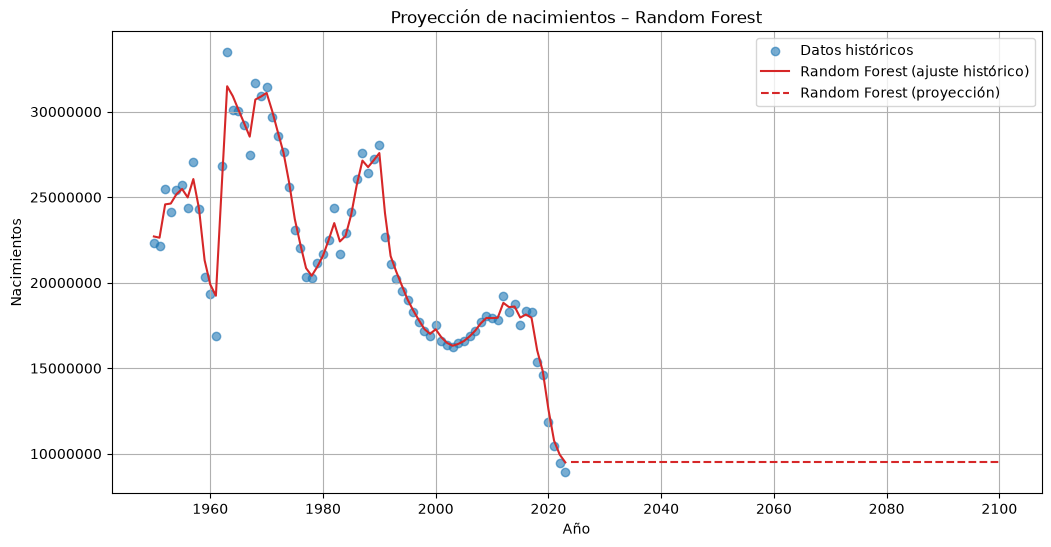

In [152]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.6
)

plt.plot(
    df_historico["Year"],
    predicciones_rf,
    color="tab:red",
    label="Random Forest (ajuste histórico)"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    linestyle="--",
    label="Random Forest (proyección)"
)

plt.title("Proyección de nacimientos – Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Observación

Fíjate en dos cosas: (1) qué tan bien sigue el modelo los datos históricos y (2) qué sucede con la línea después de 2023. ¿Continúa la tendencia? ¿Por qué crees que sucede esto? Investiga.
Sigue bastante bien los datos históricos, se pega a casi todos los picos y valles, pero después de 2020 la línea se queda fija, deja de seguir cualquier tendencia y se aplana en un valor casi constante. Esto pasa porque Random Forest no aprende una fórmula como la lineal, lo que hace es promediar grupos de datos con árboles, y esos promedios siempre van a estar dentro del rango que vio en el entrenamiento. Como nunca vio años después de 2020, cae siempre en el mismo grupito de los años más recientes y repite casi el mismo número, por eso este tipo de modelos no sirve para extrapolar al futuro.

# PARTE 13. Comparar los tres modelos

## 28. Graficar los tres modelos

Construimos una gráfica que permita comparar directamente los resultados.

> Si la regresión polinomial genera valores muy extremos y no permite ver bien las demás curvas, puedes limitar el eje vertical agregando, por ejemplo, `plt.ylim(0, 3_500_000)` antes de `plt.show()`.

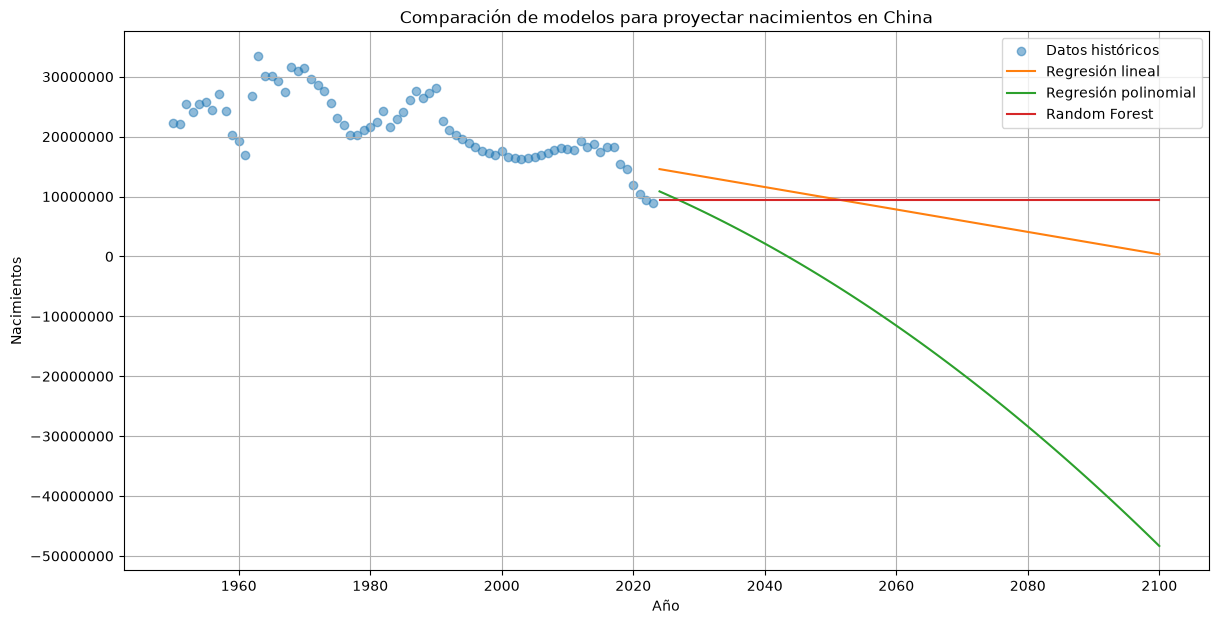

In [153]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar nacimientos en China"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# PARTE 14. Repetir el proceso para defunciones

Hasta este momento construimos modelos para predecir **nacimientos**. Ahora repetiremos el mismo proceso para **defunciones**.

## 29. Preparar la variable objetivo

La variable predictora sigue siendo `X` (el año). Solo cambia la variable objetivo:

In [154]:
y_defunciones = df_historico["deaths"]

## 30. Regresión lineal para defunciones

In [155]:
modelo_lineal_deaths = LinearRegression()

modelo_lineal_deaths.fit(
    X,
    y_defunciones
)

predicciones_lineal_deaths = modelo_lineal_deaths.predict(
    X_futuro
)

## 31. Regresión polinomial para defunciones

Utilizamos nuevamente las variables construidas con `PolynomialFeatures` (`X_poly` y `anios_futuros_poly`).

In [156]:
modelo_polinomial_deaths = LinearRegression()

modelo_polinomial_deaths.fit(
    X_poly,
    y_defunciones
)

predicciones_polinomiales_deaths = modelo_polinomial_deaths.predict(
    anios_futuros_poly
)

## 32. Random Forest para defunciones

In [157]:
modelo_rf_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_deaths.fit(
    X,
    y_defunciones
)

predicciones_rf_deaths = modelo_rf_deaths.predict(
    X_futuro
)

# PARTE 15. Comparar las predicciones de defunciones

## 33. Visualizar los tres modelos

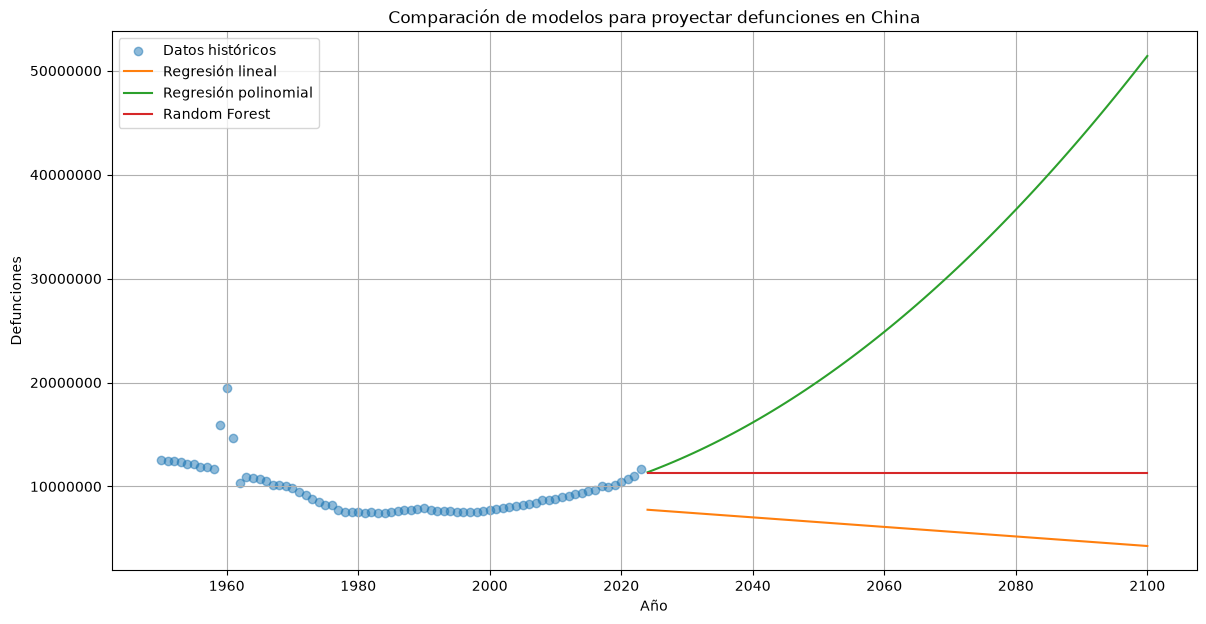

In [158]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_historico["Year"],
    df_historico["deaths"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Comparación de modelos para proyectar defunciones en China"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# PARTE 16. Comparar nuestros modelos con las proyecciones de OWID

Finalmente, agregamos a las gráficas las **proyecciones proporcionadas por OWID** (las de la ONU, escenario medio). Estas proyecciones no se obtienen ajustando una recta a la serie histórica: se construyen con modelos demográficos que consideran fecundidad, mortalidad y estructura por edad de la población.

## 34. Nacimientos: ML vs OWID

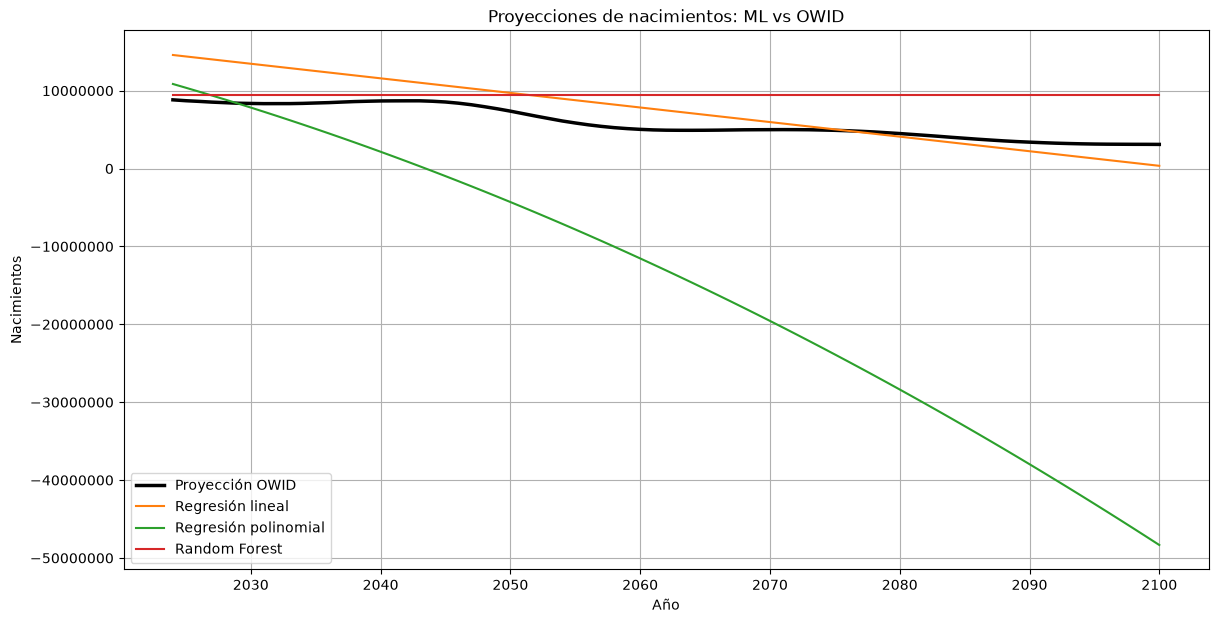

In [159]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["births"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_futuras,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_futuras,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_futuras,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de nacimientos: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Nacimientos")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 35. Defunciones: ML vs OWID

Repetimos el ejercicio para defunciones.

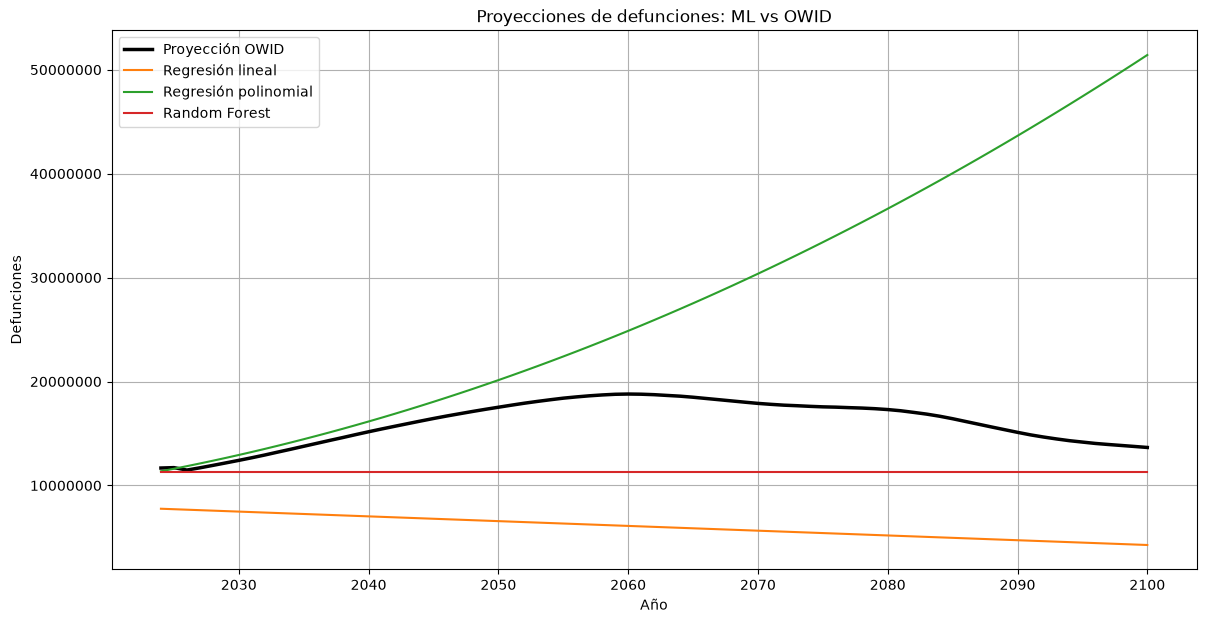

In [160]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_proyectado["Year"],
    df_proyectado["deaths"],
    color="black",
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_lineal_deaths,
    color="tab:orange",
    label="Regresión lineal"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_polinomiales_deaths,
    color="tab:green",
    label="Regresión polinomial"
)

plt.plot(
    anios_futuros.flatten(),
    predicciones_rf_deaths,
    color="tab:red",
    label="Random Forest"
)

plt.title(
    "Proyecciones de defunciones: ML vs OWID"
)

plt.xlabel("Año")
plt.ylabel("Defunciones")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 36. Resumen numérico (opcional)

A veces es útil ver los números y no solo la gráfica. Esta tabla muestra lo que predice cada modelo para algunos años seleccionados:

In [161]:
anios_tabla = [2030, 2050, 2075, 2100]
indice = anios_futuros.flatten()


def construir_tabla(owid, lineal, polinomial, rf):
    tabla = pd.DataFrame(
        {
            "OWID": owid.set_index("Year").reindex(indice).to_numpy().ravel(),
            "Regresión lineal": lineal,
            "Regresión polinomial": polinomial,
            "Random Forest": rf,
        },
        index=indice
    )
    tabla.index.name = "Año"
    return tabla.loc[anios_tabla]


print("NACIMIENTOS")
display(
    construir_tabla(
        df_proyectado[["Year", "births"]],
        predicciones_lineal_futuras,
        predicciones_polinomiales_futuras,
        predicciones_rf_futuras
    ).style.format("{:,.0f}")
)

print("DEFUNCIONES")
display(
    construir_tabla(
        df_proyectado[["Year", "deaths"]],
        predicciones_lineal_deaths,
        predicciones_polinomiales_deaths,
        predicciones_rf_deaths
    ).style.format("{:,.0f}")
)

NACIMIENTOS


AttributeError: The '.style' accessor requires jinja2

# PARTE 17. Reflexión

Responde las siguientes preguntas en esta misma celda (haz doble clic para editarla).

### 1.
¿Qué diferencia observaste entre la regresión lineal, la regresión polinomial y Random Forest?

*Respuesta:*
La lineal traza una sola recta y se extrapola sin límite; la polinomial se ajusta mejor a la curva histórica pero se dispara feo al salir del rango; y la random Forest le atina bien a lo histórico pero se aplana y deja de predecir tendencia después de 2020

### 2.
¿Por qué los tres modelos generan predicciones diferentes si utilizaron los mismos datos históricos?

*Respuesta:*
Porque cada modelo entiende la relación entre año y nacimientos de forma distinta, y aunque tenian los mismos datos, cada uno generaliza diferente fuera de ese rango.

### 3.
¿Qué modelo produjo una tendencia más cercana visualmente a las proyecciones de OWID?

*Respuesta:*
Depende de la variable. En nacimientos, la polinomial se dispara demasiado rápido hacia negativos, así que Random Forest probablemente se acerque más en el corto plazo simplemente porque no se sale de los valores ya conocidos, aunque tampoco es porque "entienda" la tendencia futura, solo se queda cerca del último valor que vio.

### 4.
¿El modelo que visualmente parece acercarse más a las proyecciones de OWID necesariamente es el mejor modelo? Explica.

*Respuesta:*
No, que se vea parecido no significa que sea bueno, a lo mejor nomás le atinó de pura suerte en ese tramo, o hasta puede estar sobreajustado. Para saber cual es el mejor de verdad hay que medirlo con métricas, no solo verlo.

### 5.
¿Qué comportamiento observaste en las predicciones de Random Forest para los años posteriores a 2023?

*Respuesta:*
Se puso plano, básicamente predice casi el mismo valor sin importar qué tan lejos esté el año, porque no puede salirse del rango que aprendió en el entrenamiento.

### 6.
¿Por qué debemos tener cuidado al utilizar un modelo entrenado con datos históricos para realizar predicciones hasta el año 2100?

*Respuesta:*
Porque estamos yendo muy lejos del rango con el que se entrenó y nada garantiza que el patrón del pasado se mantenga. Pueden pasar un buen de cosas que el modelo nunca vio, y entre más lejos vayas en el tiempo más se puede alejar la predicción de la realidad.

# PARTE 18. Conceptos clave

Al finalizar la práctica, debes poder identificar:

| Concepto | Significado |
|---|---|
| **Variable predictora** | Variable utilizada por el modelo para generar una predicción |
| **Variable objetivo** | Variable que queremos predecir |
| **Entrenamiento** | Proceso mediante el cual el modelo aprende a partir de los datos |
| **Predicción** | Resultado generado por el modelo |
| **Regresión lineal** | Modelo que representa una relación lineal |
| **Regresión polinomial** | Extensión que permite representar relaciones curvas |
| **Random Forest** | Modelo basado en múltiples árboles de decisión |
| **Extrapolación** | Generación de predicciones fuera del rango de datos utilizados para entrenar el modelo |

> **Importante:** En esta práctica solamente hemos **construido y utilizado** los modelos. En la siguiente práctica aprenderemos a **evaluar su desempeño mediante métricas**, para determinar qué tan bien están realizando sus predicciones.